# 01 - Data Overview

## Purpose and Scope

This notebook constitutes the initial and highly critical **Exploratory Data Analysis (EDA)** phase, rigidly determining the machine learning and AI-backed feature engineering strategies of the thesis. By dissecting the raw calibrations of the Alibaba PAI 100K GPU job sample, it empirically anchors the objective decisions dictating exactly which data the ensuing models (e.g., Random Forest, LightGBM, CNN, LSTM) will be trained upon and establishes the statistical validity of said data.

The investigations executed at this stage directly justify the following ultimate architectural preferences of the thesis:

1. **Data Integrity and Missing Values:** Thoroughly detecting incomplete or corrupted records within the raw cluster trace to sterilize the dataset, fundamentally preventing deep neural networks (like the LSTM) from encountering anomalies or exploding gradients during backward propagation.
2. **Cardinality of Categorical Features:** Statistically analyzing dimensions such as `user` and `gpu_type` to empirically defend why Native Categorical approaches (e.g., in LightGBM) are actively tested against standard One-Hot encoding to avoid dimensionality explosion.
3. **Discriminative Distributions:** Conducting variance analysis on structural inputs (vCPUs, Memory, Instance Count) to pinpoint which architectural columns actually encode genuine 'predictive power' for the subsequent machine learning engines.
4. **Raw Time-Series Quality Assurance:** Validating the chronological integrity of timestamped records to prove the absolute sequential reliability of the event trace that will eventually feed the custom `MultiNodeClusterSimulator` engine.

The comprehensive findings derived here forge a definitively data-driven foundation upon which the ensuing Workload Characterization (Notebook 02) and Feature Engineering (Notebook 03) phases are rigidly constructed.


In [1]:
# ── 0. Environment & Path Setup ──────────────────────────────────────────────
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Anchor on a marker that only exists at the repository root, so the notebook
# works regardless of the directory the kernel was started from. parents[1]
# resolved one level short when the working directory was notebooks/.
def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    return start.parents[1]

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"[Setup] Project root : {PROJECT_ROOT}")
print(f"[Setup] Python path  : {sys.executable}")

[Setup] Project root : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling
[Setup] Python path  : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling/venv/bin/python


> **Environment verified.** Project root added to Python path; data directories validated
> via `configs/paths.yaml`. Notebook is ready to run reproducibly.


In [2]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
# stdlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project
from src.data_loading import load_main_sample
from src.feature_engineering import build_job_table_from_sample

# Unified visualisation theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.family": "DejaVu Sans",
    # ── Publication-grade output ───────────────────────────────────────────
    # scripts/export_thesis_results.py scrapes the notebook's own inline PNG,
    # so the inline dpi is what reaches the thesis. At the 100 dpi default
    # these exported at 147-280 ppi, under the 300 ppi publisher floor.
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    # Figures are authored on a generous canvas, 10 to 18 in, and printed into
    # a 6.10-in column, roughly a 0.35 to 0.55x reduction. Shrinking the canvas
    # to match the print width made every panel cramped, so the canvas stays
    # and the type is scaled instead: at 15 pt a 14-in figure prints at 6.5 pt,
    # above the ~6 pt legibility floor.
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 19,
})

print("[Setup] All imports OK.")


[Setup] All imports OK.


> **Dependencies loaded.** Pandas, NumPy, Matplotlib, Seaborn and `src` modules imported
> successfully. Visualisation parameters (`rcParams`) configured.


The dataset contains 100,000 jobs with 8 attributes, and no missing values are present in any column, eliminating the need for additional missing-data handling.

Numerical features (e.g., num_gpu, num_cpu, duration) are stored in appropriate numeric data types, while categorical attributes (user, gpu_type) are represented as object types.

In [3]:
# ── 2. Load Dataset ───────────────────────────────────────────────────────────
print("[Step 1] Loading raw dataset...")
raw_df = load_main_sample()

print(f"[Step 1] Shape   : {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
raw_df.head()

[Step 1] Loading raw dataset...
[Step 1] Shape   : 100,000 rows × 8 columns


,job_id,num_inst,submit_time,num_cpu,num_gpu,gpu_type,duration,user
0,0,1.0,0,2.0,0.00,CPU,34,d4d51aca8806
1,1,12.0,3,6.0,0.25,T4,15748,d4d51aca8806
2,2,1.0,5,6.0,1.00,MISC,84,a8192d6b0ae9
3,3,1.0,21,18.0,1.00,T4,46,c7152ce0fec1
4,4,1.0,21,6.0,1.00,MISC,80,7b76597f4283


> **Raw dataset loaded: 100,000 job records.** The entire dataset is in memory. The trace
> ships one row per job with a recorded `duration`; the next two cells confirm per column
> that nothing is missing.


In [4]:
# ── 3. Column types and null counts ──────────────────────────────────────────
print("[Step 2] Schema inspection — dtypes and null counts")
raw_df.info()

[Step 2] Schema inspection — dtypes and null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   job_id       100000 non-null  int64  
 1   num_inst     100000 non-null  float64
 2   submit_time  100000 non-null  int64  
 3   num_cpu      100000 non-null  float64
 4   num_gpu      100000 non-null  float64
 5   gpu_type     100000 non-null  object 
 6   duration     100000 non-null  int64  
 7   user         100000 non-null  object 
dtypes: float64(3), int64(3), object(2)
memory usage: 6.1+ MB


> **Column types and null counts reported.** Numeric columns (`num_gpu`, `num_cpu`,
> `duration`) confirmed as correct types. `raw_df.info()` reports 100,000 non-null entries
> for every one of the 8 columns; the next cell states the same result explicitly.


In [5]:
# ── 4. Missing value summary ──────────────────────────────────────────────────
missing = raw_df.isnull().sum()
missing_pct = (missing / len(raw_df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_%", ascending=False)

if missing_summary.empty:
    print("[Step 2] No missing values detected.")
else:
    print("[Step 2] Columns with missing values:")
    display(missing_summary)

[Step 2] No missing values detected.


> **Missing value analysis complete.** No column of the raw trace contains a missing
> value, so no record is filtered out for a missing or non-positive duration. The 17,816
> records removed in the next step are the CPU-only jobs (`num_gpu == 0`), which the
> thesis does not model.


Job submission times are provided as normalized Unix timestamps relative to the beginning of the trace. Therefore, the analysis focuses on relative timing and inter-arrival patterns rather than absolute calendar dates.

In [6]:
# ── 5. Build canonical job table ─────────────────────────────────────────────
print("[Step 3] Building canonical job table...")
job_df = build_job_table_from_sample(raw_df, time_unit="s")

print(f"[Step 3] Valid GPU jobs : {len(job_df):,}  (filtered {len(raw_df) - len(job_df):,} invalid rows)")
job_df.describe()

[Step 3] Building canonical job table...
[Step 3] Valid GPU jobs : 82,184  (filtered 17,816 invalid rows)


,job_id,arrival_time,arrival_sec,job_runtime,gpu_demand,num_inst,num_cpu
count,82184.000000,82184,82184.000000,82184.000000,82184.000000,82184.000000,82184.000000
mean,50211.736713,1970-01-04 17:18:34.684865667,321511.684866,5223.019408,0.680211,5.007873,6.916216
min,1.000000,1970-01-01 00:00:03,0.000000,4.000000,0.010000,1.000000,0.040000
25%,25865.500000,1970-01-02 17:17:39.250000,148656.250000,153.000000,0.250000,1.000000,6.000000
50%,50284.500000,1970-01-04 12:00:23.500000,302420.500000,594.000000,0.500000,1.000000,6.000000
75%,75070.250000,1970-01-06 17:03:11.750000,493388.750000,4126.000000,1.000000,1.000000,6.000000
max,99999.000000,1970-01-08 15:51:32,661889.000000,599445.000000,8.000000,512.000000,90.000000
std,28695.483592,NaN,195452.663528,15980.719087,0.560444,14.652502,4.060256


> **Canonical job table built: 82,184 valid GPU jobs.** The 17,816 removed records are
> exactly the CPU-only ones (`num_gpu == 0`): `build_job_table_from_sample()` is called
> here with its default `include_cpu_only=False`. Nothing is dropped for a missing or
> non-positive runtime, because the trace contains no such row. This table forms the basis
> for all analyses in Notebooks 03–05.


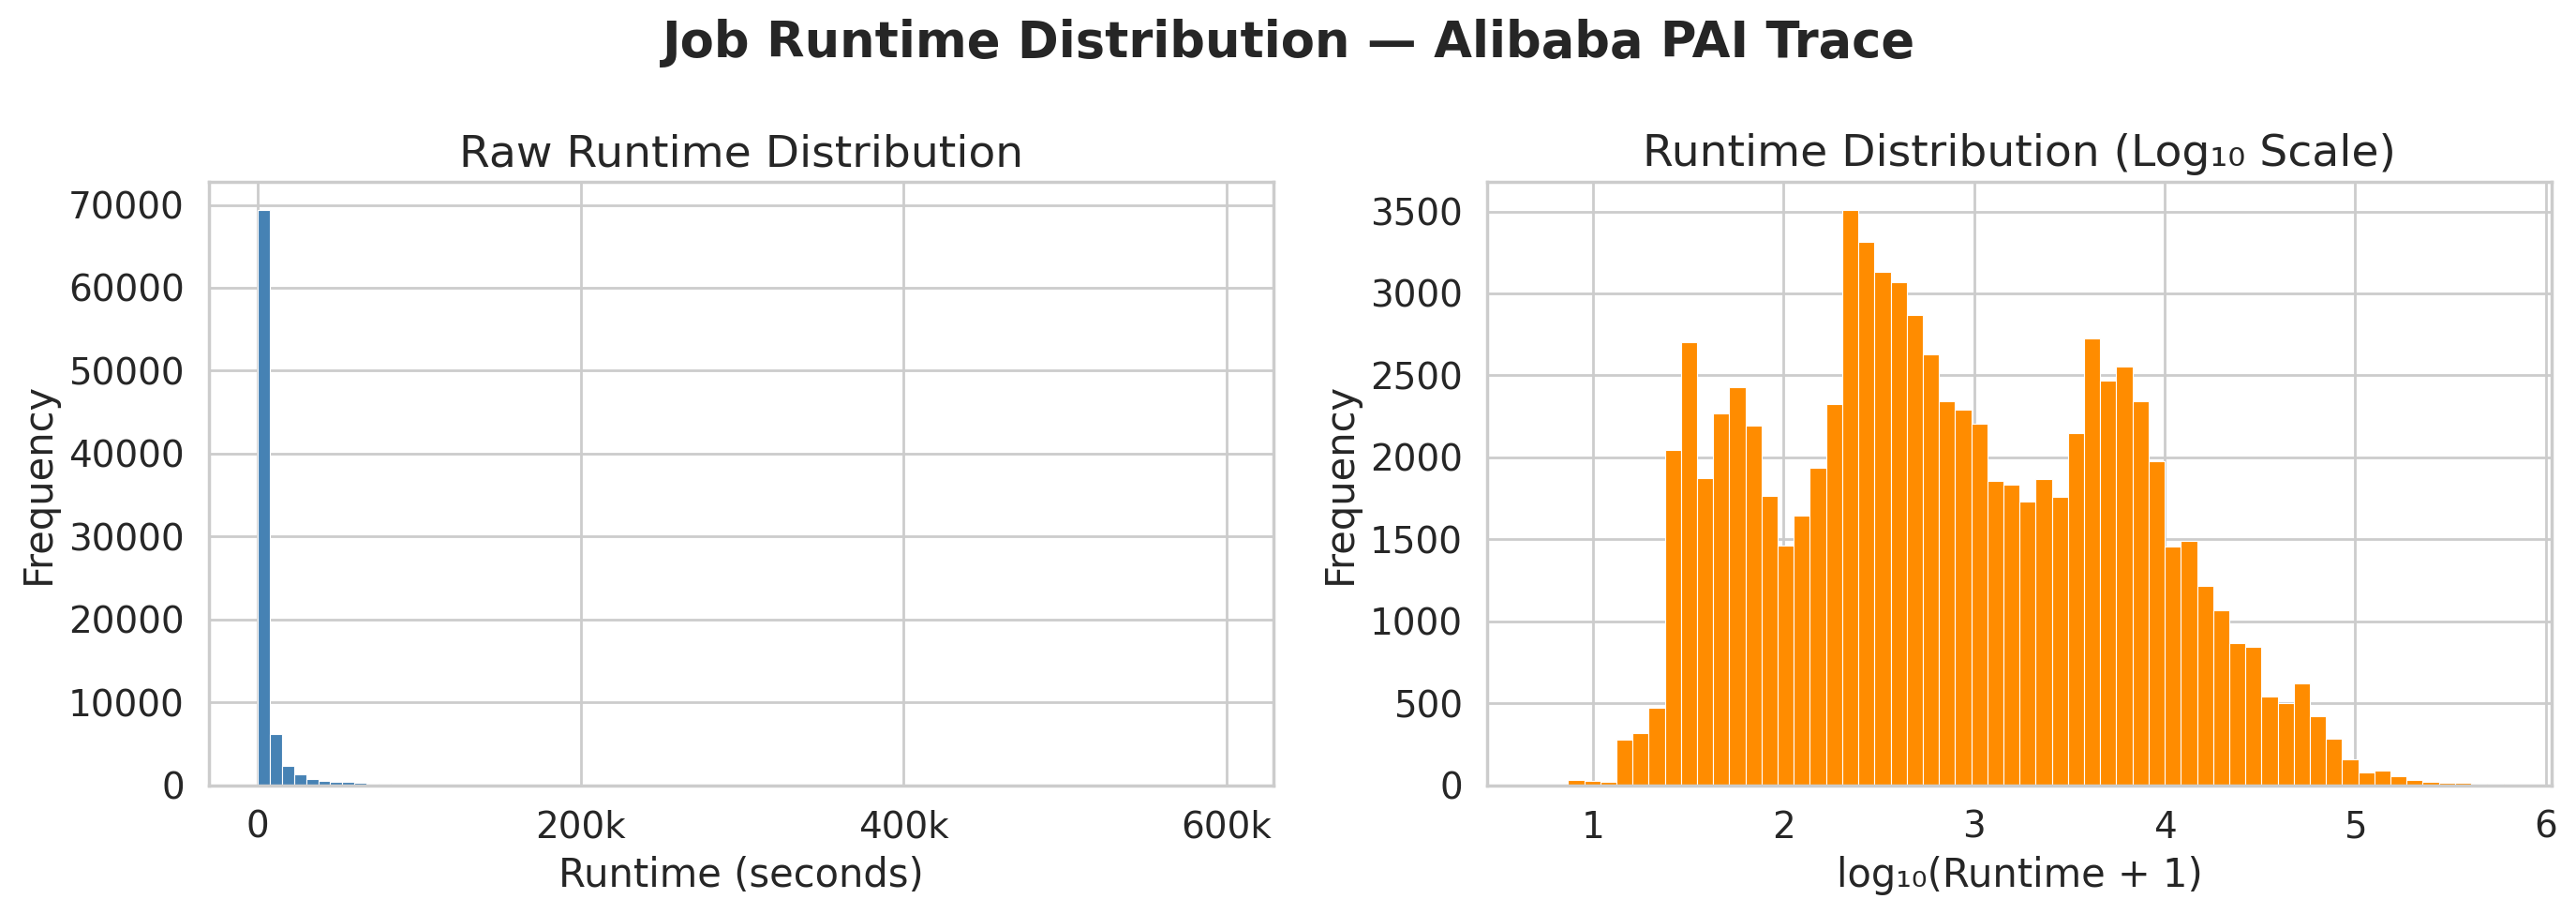

In [7]:
import matplotlib.ticker as mticker
# Hard-coded sizes rescaled with the figure: these override rcParams, so
# leaving them at the old values would keep the labels this figure was resized
# for at their old printed size.
# ── 6. Runtime histogram (log scale) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw seconds
axes[0].hist(job_df["job_runtime"], bins=80, color="steelblue", edgecolor="white", linewidth=0.4)
# Six-figure second counts do not fit under a 3.5-inch panel: at the printed
# width the default ticks ran together into "100000200000300000".
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(4))
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _p: f"{v/1000:,.0f}k" if v else "0"))
# The formatter above already renders "200k", so the label must not repeat
# the scale, "200k thousands of seconds" is the reading it would invite.
axes[0].set_xlabel("Runtime (seconds)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Raw Runtime Distribution")

# Right: log10 transform
log_runtimes = np.log10(job_df["job_runtime"] + 1)
axes[1].hist(log_runtimes, bins=60, color="darkorange", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("log₁₀(Runtime + 1)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Runtime Distribution (Log₁₀ Scale)")

# "100K" named the raw file, but these panels plot the filtered GPU-job subset
# of 82,184 rows, so the old title overstated n by ~22%.
plt.suptitle("Job Runtime Distribution — Alibaba PAI Trace", fontsize=19, fontweight="bold")
plt.tight_layout()
plt.show()

> **Figure 1 — Runtime Distribution (Raw and Log₁₀ Scale):** The two panels must be
> read together. Left panel (blue): In raw scale the distribution is **extremely right-skewed**
> — nearly all jobs cluster in the 0–20,000 s band while the right tail extends to 600,000 s.
> Right panel (orange): In Log₁₀ scale the distribution is **bimodal** — two peaks are visible
> near log₁₀≈2.5 (~300 s) and log₁₀≈3.6–3.7 (~4,000–5,000 s). This bimodal structure
> suggests two distinct job archetypes in the cluster: short inference jobs and long training jobs.
>
> **Implication for model selection:** The right-skewed + heavy-tail structure makes the MSE
> loss function inappropriate (disproportionately penalises outliers). MAE and MdAE are
> preferred; linear models cannot adequately represent this distribution.


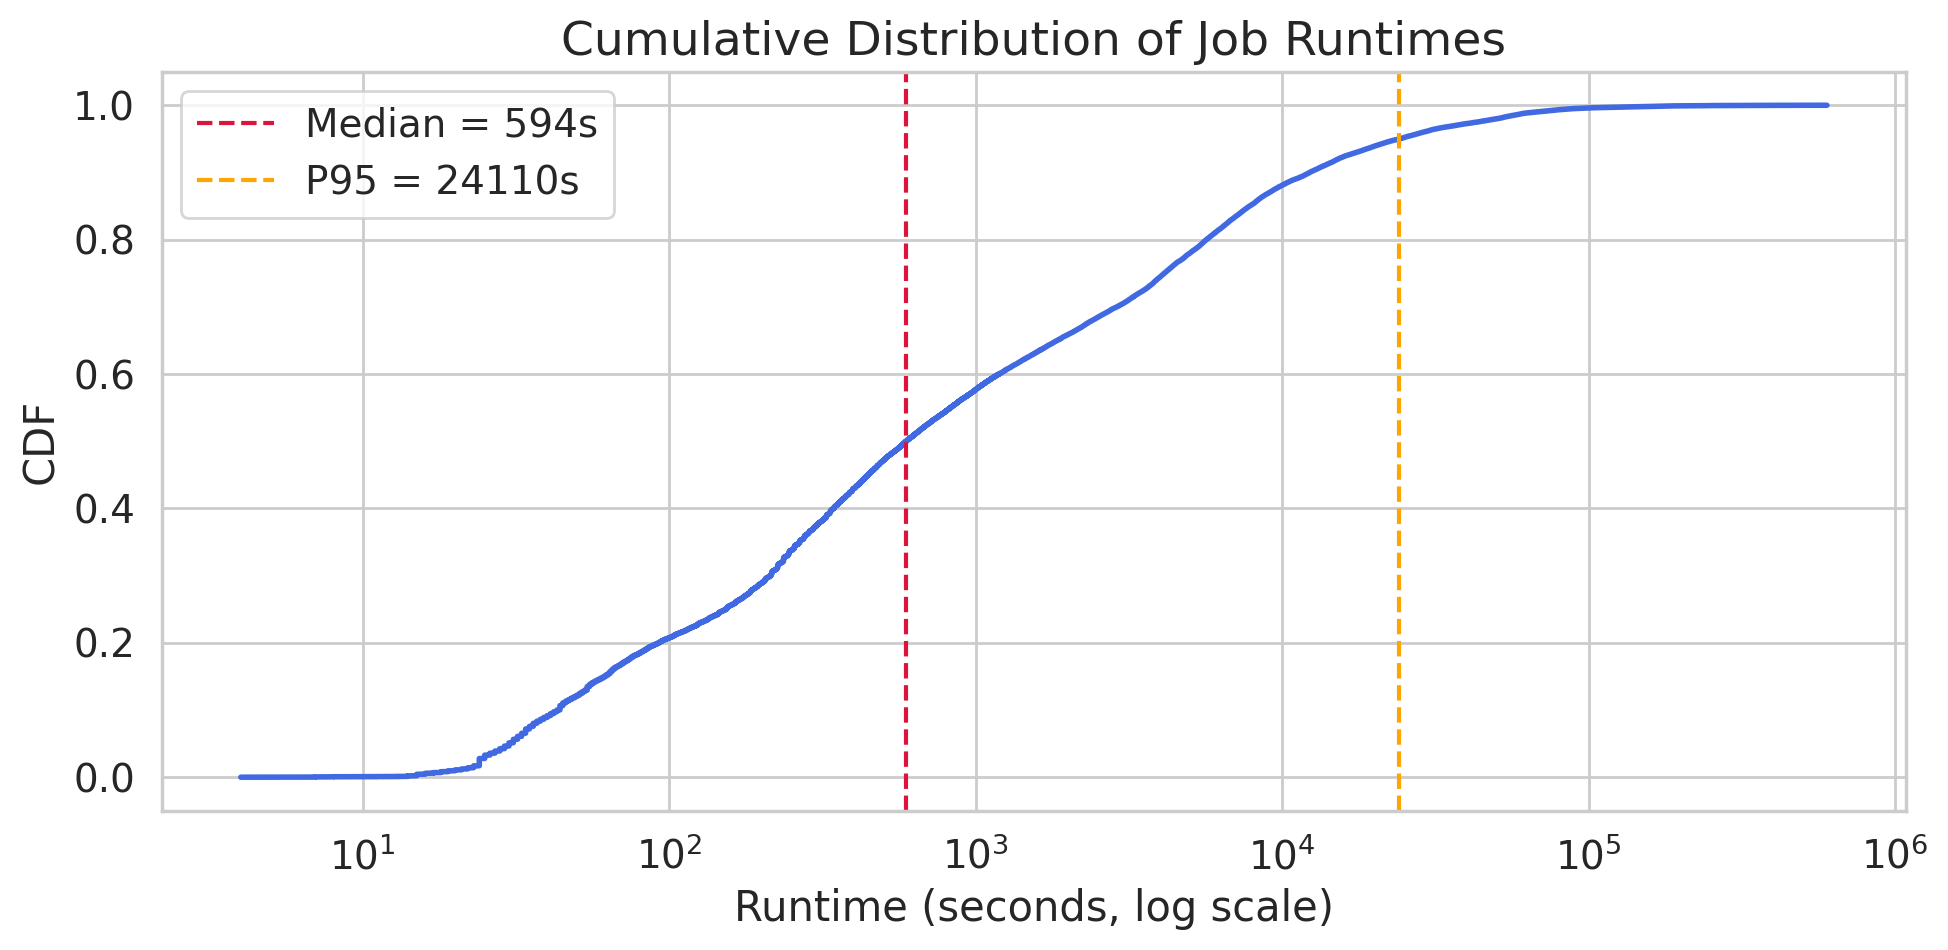

P50  :        594 s
P95  :     24,110 s
P99  :     67,432 s
Max  :    599,445 s


In [8]:
# ── 7. Runtime CDF ────────────────────────────────────────────────────────────
runtimes_sorted = np.sort(job_df["job_runtime"].values)
cdf = np.arange(1, len(runtimes_sorted) + 1) / len(runtimes_sorted)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(runtimes_sorted, cdf, lw=2, color="royalblue")
ax.axvline(np.median(runtimes_sorted), color="crimson", ls="--", label=f"Median = {np.median(runtimes_sorted):.0f}s")
ax.axvline(np.percentile(runtimes_sorted, 95), color="orange", ls="--", label=f"P95 = {np.percentile(runtimes_sorted, 95):.0f}s")
ax.set_xscale("log")
ax.set_xlabel("Runtime (seconds, log scale)")
ax.set_ylabel("CDF")
ax.set_title("Cumulative Distribution of Job Runtimes")
ax.legend()
plt.tight_layout()
plt.show()

p50 = np.percentile(runtimes_sorted, 50)
p95 = np.percentile(runtimes_sorted, 95)
p99 = np.percentile(runtimes_sorted, 99)
print(f"P50  : {p50:>10,.0f} s")
print(f"P95  : {p95:>10,.0f} s")
print(f"P99  : {p99:>10,.0f} s")
print(f"Max  : {runtimes_sorted[-1]:>10,.0f} s")

> **Figure 2 — Runtime Cumulative Distribution Function (CDF):** The numerical values
> read directly from the figure:
> - **P50 (Median) = 594 s** (~10 min): Half of all jobs complete within 10 minutes.
> - **P95 = 24,110 s** (~6.7 hours): 95% of jobs complete within 6.7 hours.
> - **P99 = 67,432 s** (~18.7 hours): The top 1% runs longer than 18 hours.
> - **Max = 599,445 s** (~7 days): The longest job runs for nearly a full week.
>
> **Tail ratio P95/P50 ≈ 40.6** — an extraordinarily high value. (This ratio is not the
> coefficient of variation; on the same 82,184 jobs the CV, std/mean, is 3.06 — still far
> above the CV = 1 of an exponential distribution.) Such dispersion is why FIFO decisions
> taken on mean statistics cause critical Head-Of-Line blocking in worst-case scenarios.
> The gain potential of the SJF policy is directly proportional to this variance.


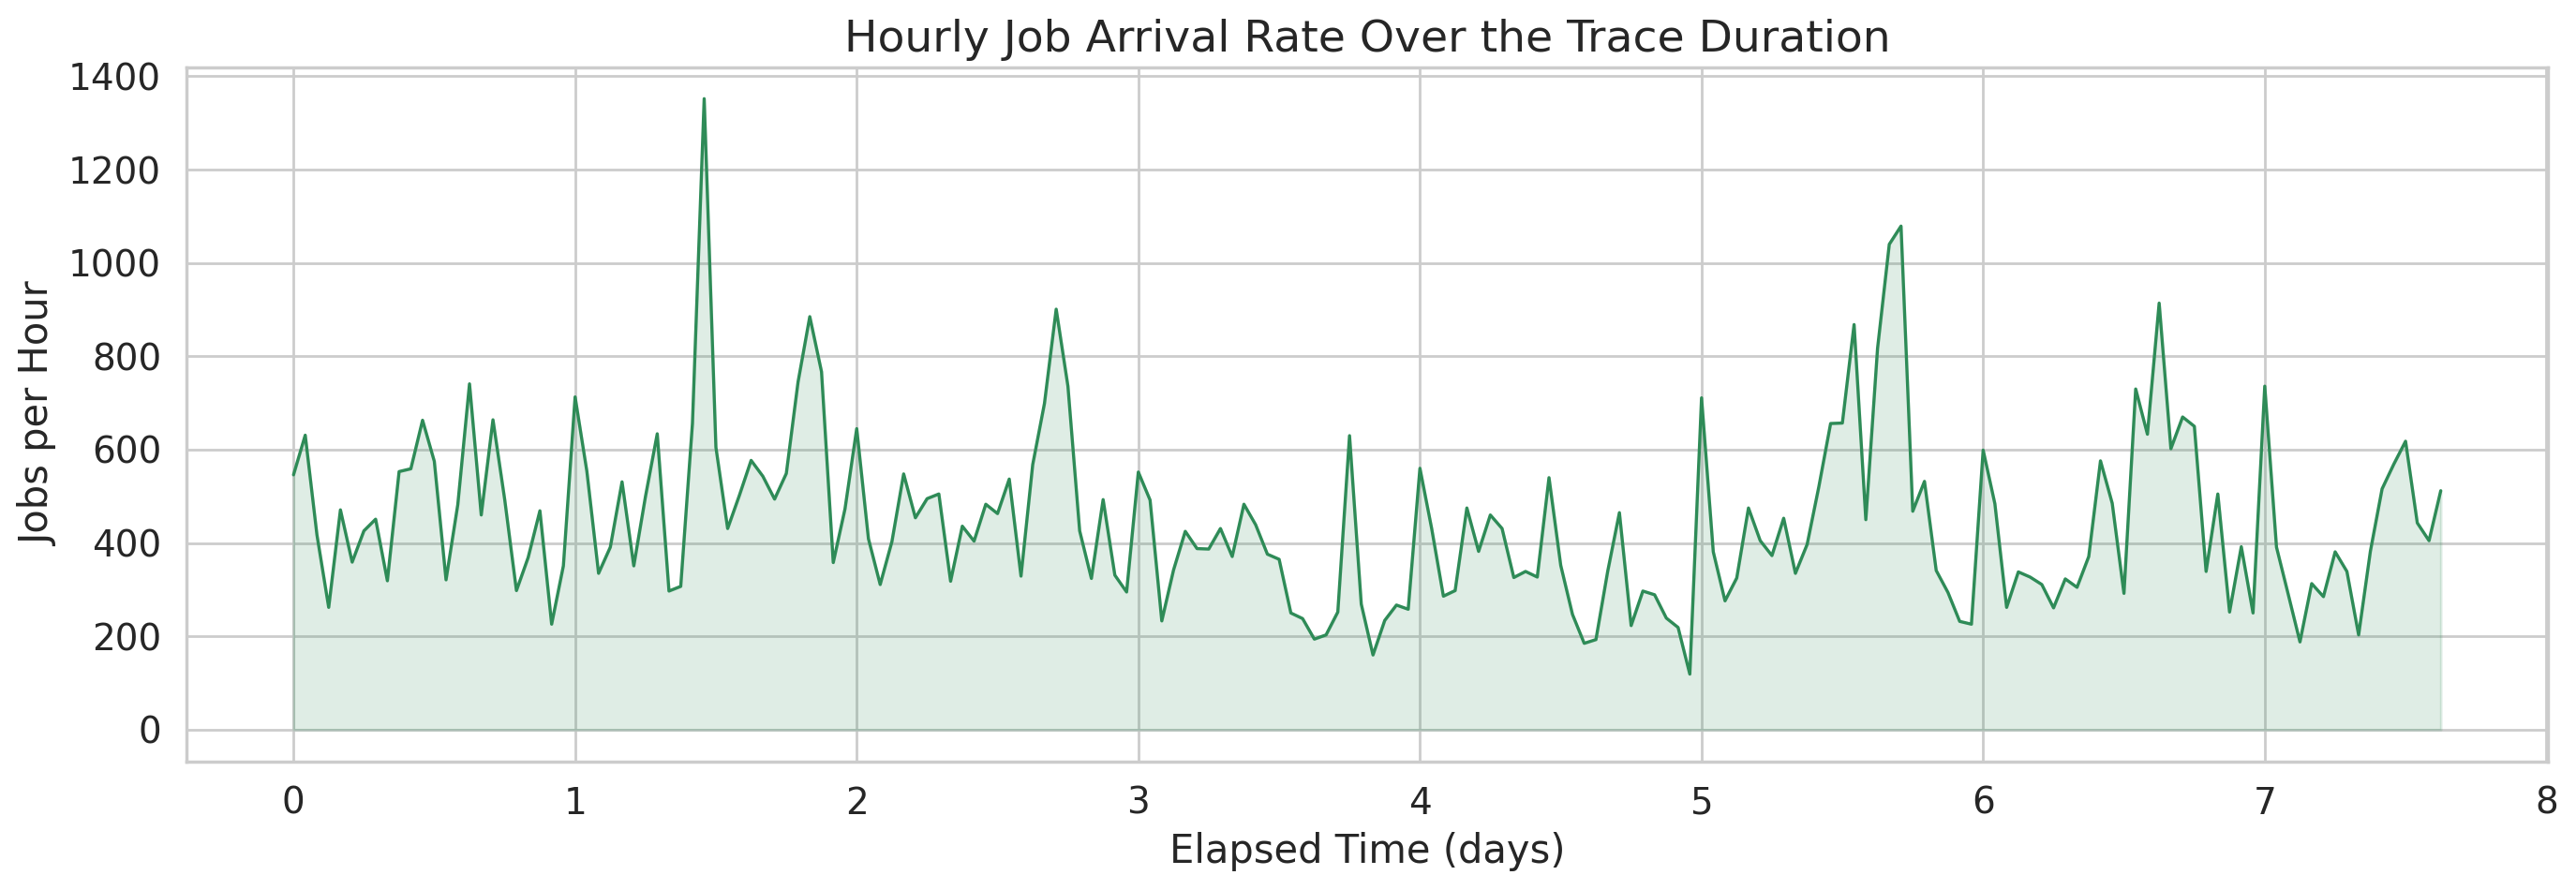

In [9]:
# ── 8. Hourly arrival rate ─────────────────────────────────────────────────-
# Use lowercase "1h" alias — uppercase "1H" is deprecated in pandas >= 2.2
arrival_series = (
    job_df.set_index("arrival_time")["job_id"]
    .resample("1h")
    .count()
)
hours = arrival_series.index.total_seconds() / 3600 if hasattr(arrival_series.index[0], 'total_seconds') else         (arrival_series.index - arrival_series.index[0]).total_seconds() / 3600

days = hours / 24

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(days, arrival_series.values, lw=1.2, color="seagreen")
ax.fill_between(days, arrival_series.values, alpha=0.15, color="seagreen")
ax.set_xlabel("Elapsed Time (days)")
ax.set_ylabel("Jobs per Hour")
ax.set_title("Hourly Job Arrival Rate Over the Trace Duration")
plt.tight_layout()
plt.show()

> **Figure 3 — Hourly Job Arrival Rate (8-Day Trace):** The x-axis shows elapsed
> time in days (0–8), the y-axis shows jobs per hour.
> - Baseline rate: ~200–400 jobs/hr
> - Prominent peaks: day ~1.5 → **~1,350 jobs/hr**, day ~5.7 → **~1,080 jobs/hr**
> - The arrival process is not homogeneous — it exhibits a **bursty** structure.
>
> **Note on the time axis:** The horizontal axis represents **elapsed time since the start of the trace**, not the raw `arrival_time` variable.  
> `arrival_time` is `pd.to_datetime(submit_time, unit='s')` applied to a *trace-relative*  
> offset, `submit_time` starts at 0 — so it is anchored to the Unix epoch rather than to  
> the cluster's real clock. It is **not a wall-clock (UTC or local) timestamp**, and the  
> hour it yields is a 24-hour phase of unknown absolute alignment.  
> This figure visualizes the workload as an **8-day temporal series**, not as a
> distribution over hours of the day (0–23). For workload intensity by trace day and
> hour, see **Figure 6 (Trace-Day × Hour-of-Day Heatmap)**.


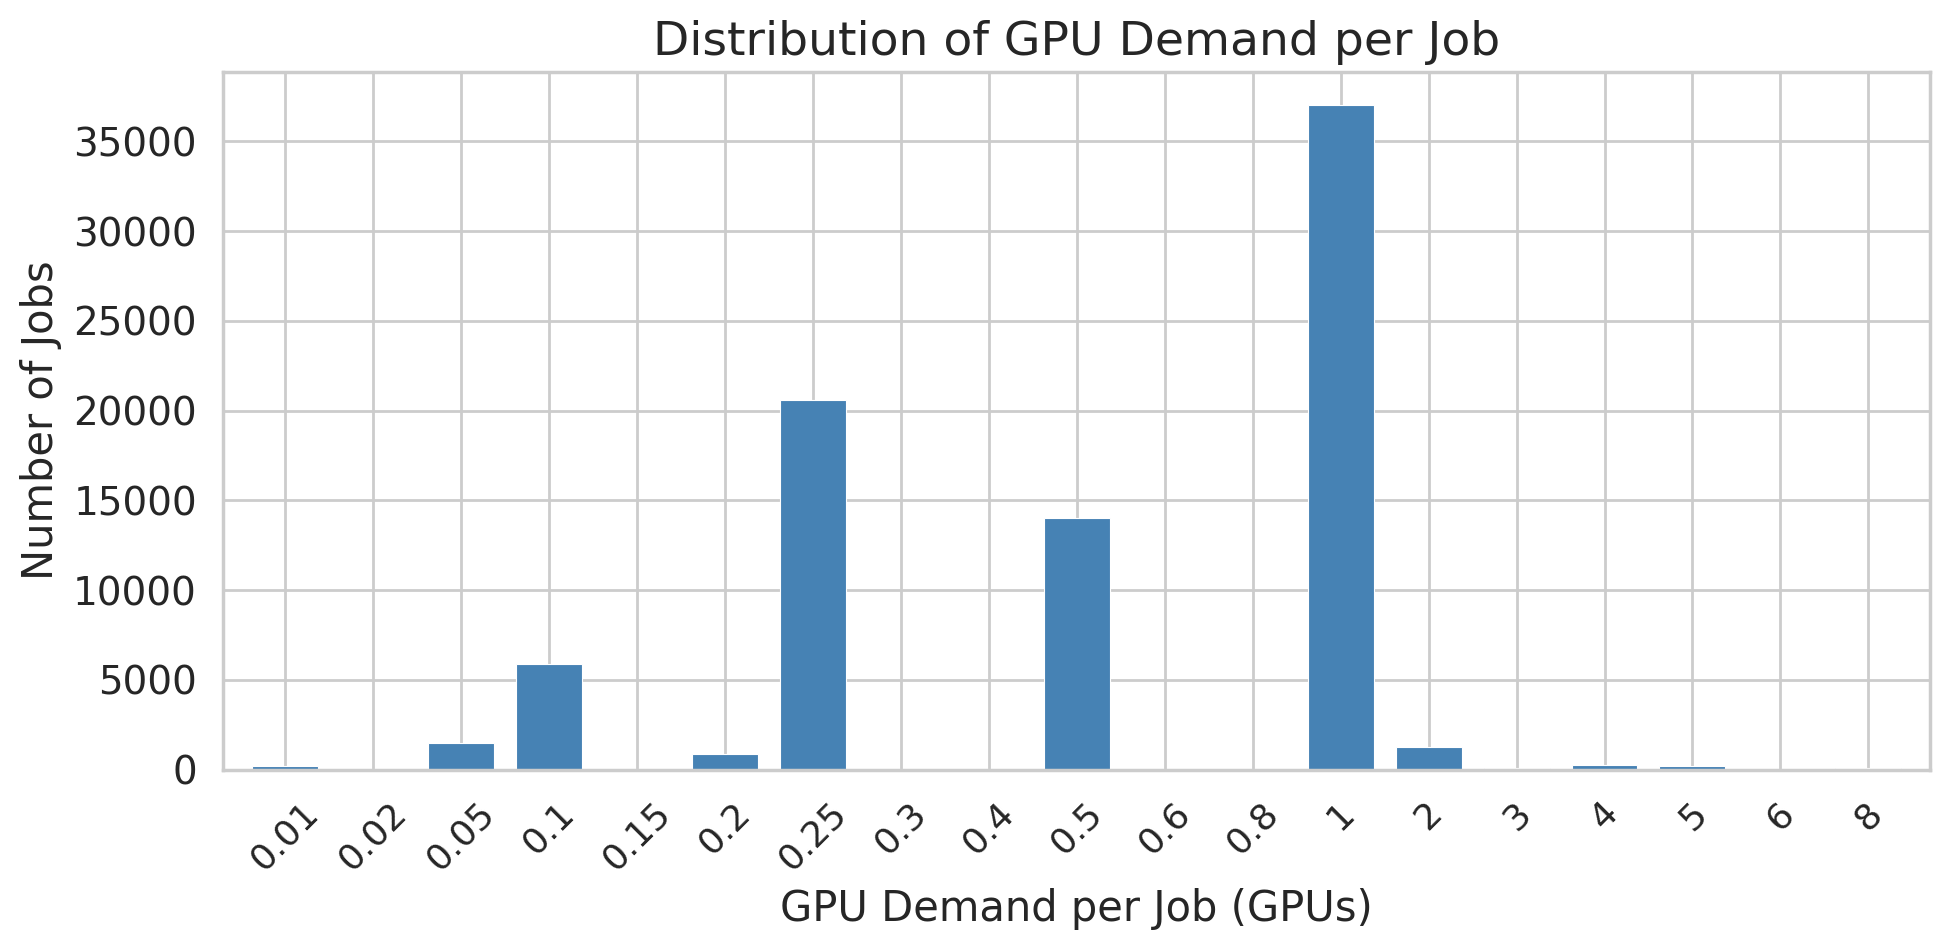

[Step 7] GPU demand statistics:
count    82184.000000
mean         0.680211
std          0.560444
min          0.010000
25%          0.250000
50%          0.500000
75%          1.000000
max          8.000000


In [10]:
# ── 9. GPU demand histogram ───────────────────────────────────────────────────
# GPU demand is not continuous here: the PAI trace records it at a small set of
# discrete levels (0.01, 0.05, ..., 1, 2, ..., 8). A log-spaced numeric axis
# spent roughly half the width on gaps no job can occupy, and with the bar
# width fixed in data units a bar's drawn width grew with its position, so area
# stopped encoding count. Equal spacing puts every observed level on the same
# footing; the level is carried by the tick label, so nothing is lost.
demand_counts = job_df["gpu_demand"].value_counts().sort_index()
_pos = np.arange(len(demand_counts))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(_pos, demand_counts.values, width=0.75,
       color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xticks(_pos)
ax.set_xticklabels([f"{v:g}" for v in demand_counts.index], rotation=45, fontsize=13)
ax.set_xlim(-0.7, len(demand_counts) - 0.3)
ax.set_xlabel("GPU Demand per Job (GPUs)")
ax.set_ylabel("Number of Jobs")
ax.set_title("Distribution of GPU Demand per Job")
plt.tight_layout()
plt.show()

print("[Step 7] GPU demand statistics:")
print(job_df["gpu_demand"].describe().to_string())

> **Figure 4 — GPU Demand Distribution:** Values read from the figure and from the
> `describe()` output printed with it:
> - **Fractional demand (0.01–0.8 GPU): 43,176 jobs** — GPU-sharing requests, more than
>   half the table; the 0.25 level alone holds 20,615 jobs.
> - **1 GPU: 37,033 jobs** — the single most common level.
> - **2 GPU: 1,274 jobs**; the 3–8 GPU levels together: 701 jobs.
> - **Median = 0.50, 25th percentile = 0.25, mean = 0.68, max = 8 GPU.**
>
> **Important:** There is no zero-GPU bar. The canonical table above was built with the
> default `include_cpu_only=False`, so the 17,816 CPU-only jobs (`num_gpu == 0`) are
> already filtered out and every job plotted here requests at least 0.01 GPU. The
> scheduling simulator (Notebook 05) likewise operates only on GPU-demanding jobs. This
> distribution explains why small jobs (≤ 1 GPU) dominate the cluster and why the
> Mid-Range (2 GPU) node profile is the most relevant one in Notebook 05.


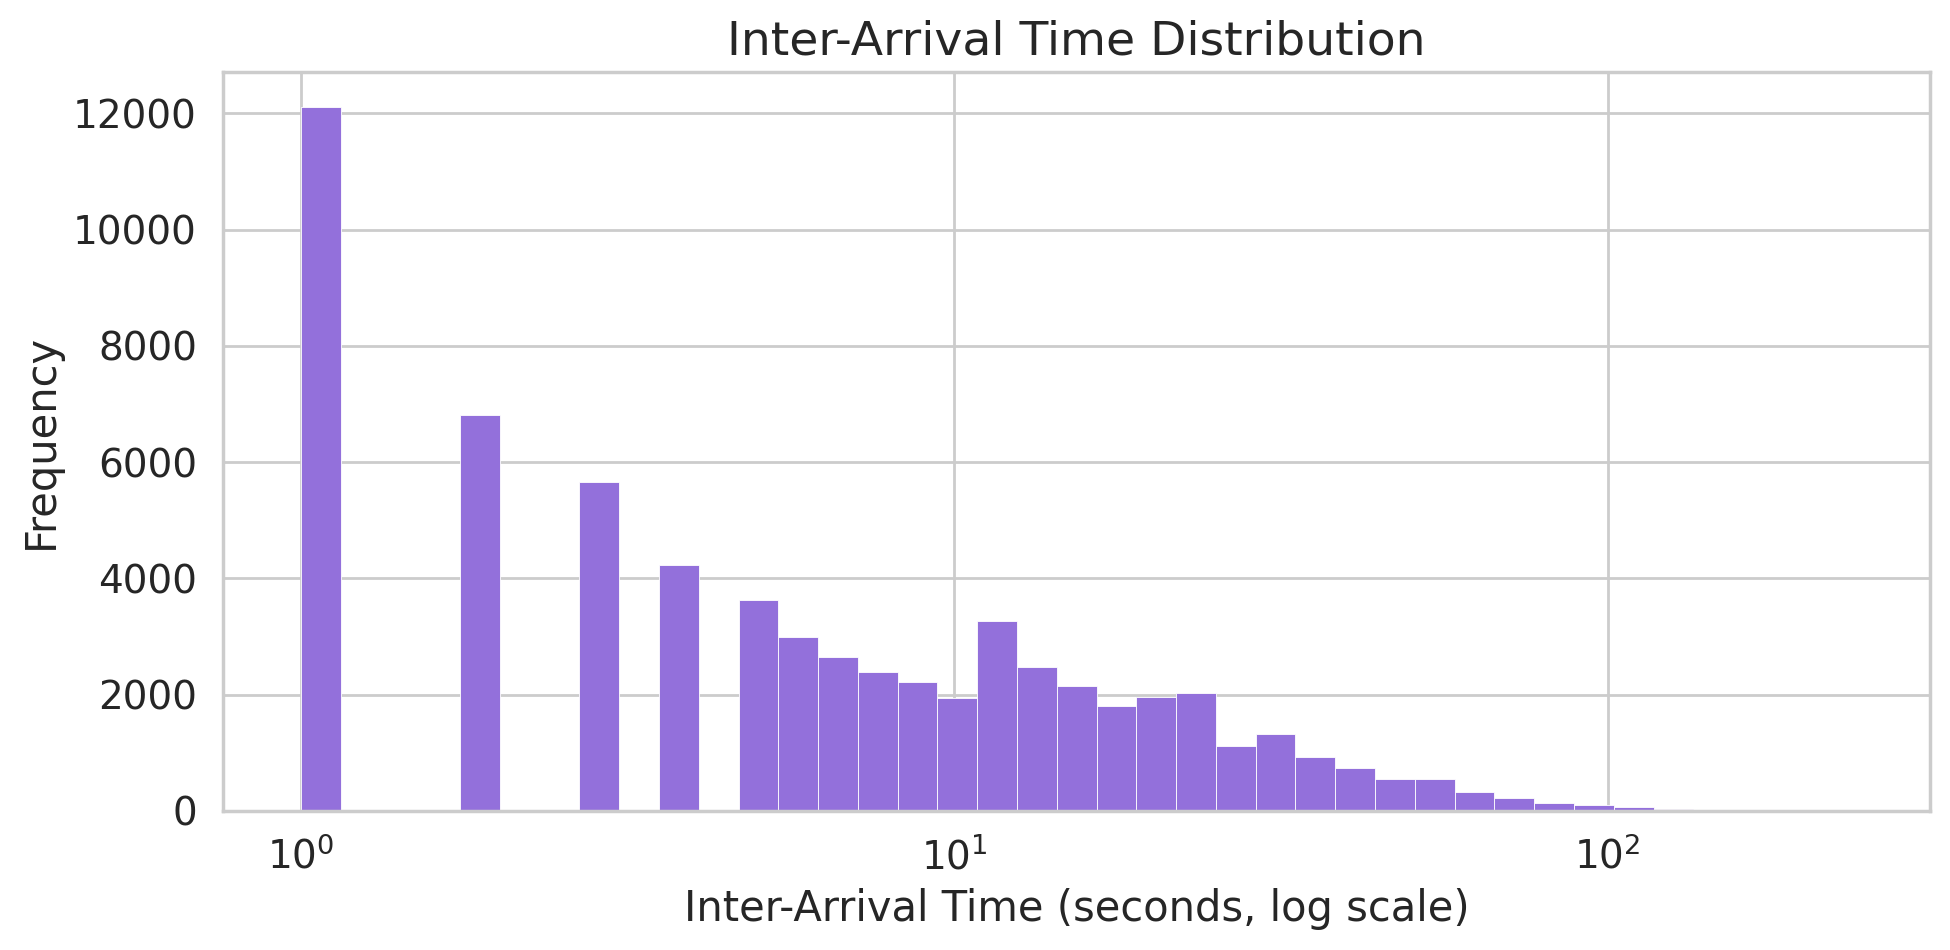

[Inter-arrival] 21.6% of consecutive job pairs arrived in the same second (excluded above; not visualizable on a log time axis).


In [11]:
# ── 10. Inter-arrival time distribution ──────────────────────────────────────
df_sorted = job_df.sort_values("arrival_time").reset_index(drop=True)
inter_arrivals_all = df_sorted["arrival_time"].diff().dt.total_seconds().dropna()
_zero_frac = float((inter_arrivals_all == 0).mean())
# Same-second (zero inter-arrival) pairs cannot be placed on a log axis and
# are reported separately rather than silently dropped from the figure.
inter_arrivals = inter_arrivals_all[inter_arrivals_all > 0]

fig, ax = plt.subplots(figsize=(10, 5))
# Log-spaced bins, not np.histogram's linear default: with bins=100 linear but
# the axis log-scaled, the smallest bin's fixed linear width covered a large
# share of the compressed low end, making "peak occurs at 1-3s" an artifact of
# bin width rather than the data.
_log_bins = np.logspace(np.log10(inter_arrivals.min()), np.log10(inter_arrivals.max()), 40)
ax.hist(inter_arrivals, bins=_log_bins, color="mediumpurple", edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_xlabel("Inter-Arrival Time (seconds, log scale)")
ax.set_ylabel("Frequency")
ax.set_title("Inter-Arrival Time Distribution")
plt.tight_layout()
plt.show()
print(f"[Inter-arrival] {_zero_frac:.1%} of consecutive job pairs arrived in the same second "
      f"(excluded above; not visualizable on a log time axis).")

> **Figure 5 — Inter-Arrival Time Distribution (Log Scale):** The x-axis shows
> inter-arrival time in log-scale seconds, the y-axis frequency. The histogram uses 40
> log-spaced bins spanning the observed range, which runs from 1 s to 237 s.
> - Tallest bin **[1.00, 1.15) s: 12,110 pairs** — a one-second gap is the single most
>   frequent case; gaps of 1 or 2 s account for 18,917 pairs in total.
> - The six occupied bins between 3 s and 9.4 s hold 18,105 pairs, the tallest of them 4,222.
> - Counts trend downwards across the 10–100 s decade, from 3,258 in the [10.8, 12.5) s
>   bin to 104 in the [88.8, 102.2) s bin.
> - Only 162 pairs reach 100 s or more, and the largest observed gap is 237 s.
> - Consecutive jobs arriving **in the same second, 21.6% of all pairs** — are excluded
>   from the figure (a zero cannot be placed on a log axis) and reported separately by the
>   cell above.
>
> **Interpretation:** The distribution is heavy-tailed rather than exponential. This proves
> that a **homogeneous Poisson process (M/M/1) is inadequate for this workload**. Burst
> periods, in which a fifth of all consecutive jobs arrive within the same second and most
> of the rest within a few seconds, give queueing delays a probabilistic rather than
> deterministic character, making the SJF advantage over FIFO dynamic.


In [ ]:
# ── 11. Day × Hour arrival heatmap ───────────────────────────────────────────
df_heat = job_df.copy()
df_heat["hour"] = df_heat["arrival_time"].dt.hour
# The trace starts at the epoch, so .dt.dayofweek encodes where the trace sits
# on the calendar rather than a real weekday, and it folds trace-day 0 and 7
# into one row. src/feature_engineering.py uses a trace-day counter and this
# figure now matches it. For the same reason the x axis is not clock time:
# submit_time starts at 0, so the hour is a 24h phase whose absolute alignment
# the trace release never discloses, and the label must not claim local time.
_t0_heat = df_heat["arrival_time"].min()
df_heat["trace_day"] = ((df_heat["arrival_time"] - _t0_heat).dt.total_seconds() // 86400).astype(int)
_n_days = int(df_heat["trace_day"].max()) + 1

heatmap_data = (
    df_heat.groupby(["trace_day", "hour"])["job_id"]
    .count()
    .unstack(fill_value=0)
    .reindex(index=range(_n_days), columns=range(24), fill_value=0)
)

# The last trace day is partial (the trace ends mid-afternoon), so its unreached
# hours are masked rather than drawn as genuine zero-arrival cells.
_hours_seen = df_heat.groupby("trace_day")["hour"].max()
_mask = pd.DataFrame(False, index=heatmap_data.index, columns=heatmap_data.columns)
for _d, _h_max in _hours_seen.items():
    _mask.loc[_d, [h for h in heatmap_data.columns if h > _h_max]] = True

fig, ax = plt.subplots(figsize=(14, 5))
# linewidths draws a grid over every cell including the masked ones, so the
# blank block for the hours the trace never reached was crossed by stray grey
# lines that read as empty-but-real cells. The masked area gets a distinct flat
# colour instead, separating "not measured" from the colormap's lowest value.
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap="YlGnBu",
    linewidths=0.3,
    mask=_mask,
    cbar_kws={"label": "Number of Jobs"},
)
ax.set_facecolor("0.85")
ax.set_xlabel("Hour Index within Trace Day (24h phase, not wall-clock time)")
ax.set_ylabel("Trace Day Index")
ax.set_title("Job Arrival Heatmap — Trace Day × Hour-of-Day")
plt.tight_layout()
plt.show()

> **Figure 6 — Job Arrival Heatmap (Trace-Day × Hour-of-Day):** The x-axis shows hour of day (0–23), the y-axis the trace-relative day index (0 = the trace's first day, counted onward; the trace spans ~7.7 days), and colour
> intensity represents job count per block (yellow ~200 → dark blue ~1,200+).
>
> **Visual patterns:** Daytime hours consistently carry heavier submission volume than late-night hours, visible across all rows of the heatmap, a clear diurnal (within-day) pattern. Volume also varies from one trace-day to the next, but **this should not be read as a Monday-through-Sunday weekly pattern** (see the note below).
>
> **Hour-axis note:** `hour_of_day` is derived from `arrival_time`, which is the trace's `submit_time` — an offset that starts at 0 at the beginning of the trace, read as seconds since the Unix epoch. The release does not disclose when the trace was actually collected, so these hours are **not UTC clock time, nor the cluster's local time**: they are a 24-hour phase of unknown absolute alignment, and "hour 9" on this axis cannot be read as 9am. The **relative diurnal pattern** — which hours are busy relative to the others within a day, is fully valid; only the absolute anchoring is unknown.
>
> **Day-index definition (corrected):** An earlier version of this notebook defined `day_of_week` as `arrival_time.dt.dayofweek` (0 = Monday, ISO-8601) and read this heatmap as showing calendar-weekday structure (e.g. a "Thursday peak"). That reading does not hold: the public Alibaba PAI trace release does not disclose its actual collection date, and the trace spans only ~7.7 days, so a true calendar-weekday encoding folds the trace's first and eighth day onto the same value, unverifiable given the undisclosed start date, and a leakage risk for the chronological train/test split, since every training occurrence of that shared value comes from the trace's first day while every test occurrence comes from its last (`leakage-1` in the scientific audit). `day_of_week` is now an absolute trace-day counter (0, 1, 2, ...) instead, and should not be read as e.g. "Monday" or "Thursday" anywhere in this analysis.

## Summary

The exploratory data analysis (EDA) conducted in this notebook has revealed critical findings
that provide an objective empirical foundation for all subsequent methodological decisions of the thesis:

- **Runtime distribution — Heavy tail:** While the median is a few minutes, the heavy-tail
  structure extends to jobs lasting hours. This distribution mandates MAE/MdAE over MSE metrics,
  and tree/deep learning models over linear alternatives.
- **GPU demand, Heterogeneous:** 80,209 of the 82,184 jobs (97.6%) request at most one GPU,
  43,176 of them only a fraction of one through GPU sharing, while 1,975 jobs request 2 to 8.
  This two-order-of-magnitude span validates multiple node profiles in the simulator.
- **Temporal pattern, Diurnal cycle:** A pronounced day/night cycle over the trace-relative
  hour axis demonstrates the necessity of temporal feature engineering and mandates
  chronological train/test splitting. (The hour axis is a 24-hour phase of unknown absolute
  alignment, see the notes on Figures 3 and 6 — so the cycle is relative, not tied to
  office hours on a real clock.)
- **User concentration:** A small user group generating heavy workload explains why One-Hot
  encoding the `user` feature causes a dimensionality explosion.

These findings ensure that every major decision in subsequent notebooks is **data-driven**, not arbitrary.
